In [1]:
import os
import sys
import time
import numpy as np
import networkx as nx

# Add src to path and import project modules
cwd = os.getcwd()
if 'src' not in os.getcwd():
    src_dir = os.path.join(cwd, 'src') if os.path.isdir(os.path.join(cwd, 'src')) else os.path.join(os.path.dirname(cwd), 'src')
    os.chdir(src_dir)
else:
    os.chdir(cwd)
sys.path.insert(0, os.getcwd())

import ep_utils as epu
import graphs as g
import ep_finder
import lep_finder

# Restore cwd if we changed it
if 'src' in os.getcwd():
    os.chdir(cwd)

In [2]:
def has_eigenbasis(A, tol=1e-10):
    vals, vecs = np.linalg.eig(A)

    # rank of eigenvector matrix
    rank = np.linalg.matrix_rank(vecs, tol=tol)

    return rank == A.shape[0]


In [80]:
def get_proper_graph(n, edge_prob=0.25, nt_perc=0.8, seed=None, directed=True):
    start = time.perf_counter()
    timeout_sec = 10
    attempt = 0
    while True:
        if time.perf_counter() - start > timeout_sec:
            raise TimeoutError("Could not find a graph with ≥80% non-singleton partition elements within 10 seconds")
        seed_i = (seed + attempt) if seed is not None else None
        G = nx.gnp_random_graph(n, edge_prob, seed=seed_i, directed=directed)
        G = nx.convert_node_labels_to_integers(G)
        GT = G.reverse(copy=True)
        ep, leps = epu.getEquitablePartitions(G, progress_bars=False)
        t_ep, t_leps = epu.getEquitablePartitions(GT, progress_bars=False)

        n_el = len(ep)
        n_non_singleton = sum(1 for nodes in ep.values() if len(nodes) > 1)
        if n_el > 0 and n_non_singleton >= nt_perc * n_el:
            if has_eigenbasis(nx.to_numpy_array(G)):#np.linalg.det(np.linalg.eig(nx.adjacency_matrix(G).todense())[1]) != 0:
                if nx.number_weakly_connected_components(G) == 1:
                    break
        attempt += 1

    return G, GT, ep, leps, t_ep, t_leps

def relabel_ep_leps(relabeler,ep,leps):
    new_ep = {}
    new_leps = []
    idxer = 0
    part_el_idxer = 0
    for lep in leps:
        new_leps.append([])
        for part_el in lep:
            new_ep[part_el_idxer] = [relabeler[n] for n in ep[part_el]]   #range(idxer,idxer + len(ep[part_el]))]
            new_leps[-1].append(part_el_idxer)
            idxer += len(ep[part_el])
            part_el_idxer += 1

    return new_ep, new_leps

def run_directed_lep_analysis(n, edge_prob=0.25, nt_perc = .8, round_val=2, seed=None, vecs=False, plot=False, directed=True):
    """
    Create a directed graph of size n, compute its equitable partition and local equitable
    partitions, then for each LEP print divisor spectrum & eigenvectors and local spectrum & eigenvectors.
    Finally print the overall divisor graph eigenvalues/eigenvectors and the full graph spectrum & eigenvectors.
    If vecs=True, eigenvectors are also printed; otherwise only eigenvalues/spectra are printed.
    Only runs on a graph whose equitable partition has at least 80% non-singleton cells; retries until found or 10s timeout.
    """
    G, GT, ep, leps, t_ep, t_leps = get_proper_graph(n,edge_prob,nt_perc,seed,directed)

    # if plot:
        # epu.plotEquitablePartition(G, ep)

    # Reorder based on ep and leps
    node_order = [node for lep in leps for ep_element in lep for node in ep[ep_element]]
    I = np.eye(n)
    P = np.array([I[j] for j in node_order])
    relabeler = {n:i for i,n in enumerate(node_order)}
    G = nx.relabel_nodes(G, relabeler)
    G = nx.convert_node_labels_to_integers(G, ordering='sorted')

    # plot if specified
    if plot:
        epu.plotEquitablePartition(G, ep)
        # transmitting partition
        epu.plotEquitablePartition(G,t_ep)
    
    ep, leps = relabel_ep_leps(relabeler,ep,leps)
    t_ep, t_leps = relabel_ep_leps(relabeler,t_ep,t_leps)
    
    # 3. Divisor matrix of the full graph (ep indices may not be 0..len(ep)-1; we need a consistent ordering)
    div_mat = g.genDivGraph(G, ep, retMat=True)
    trans_div_mat = g.genDivGraph(GT,t_ep,retMat=True)
    ep_ids = list(ep.keys())
    t_ep_ids = list(t_ep.keys())
    # genDivGraph uses enumerate(ep_dict.values()) so row i = ep_ids[i]; ensure div_mat is indexed by position
    # Actually genDivGraph iterates over ep_dict.values() so order is iteration order of keys. So div_mat[i,j] = from ep_ids[i] to ep_ids[j].
    
    

    # 4. Cycle through each LEP
    for lep_idx, lep in enumerate(leps):
        print("=" * 60)
        print(f"LEP {lep_idx}: {lep}")
        
        node_list = []
        temp_ep = {}
        for part_el_idx, part_el in enumerate(lep):
            node_list.extend(ep[part_el])
            temp_ep[part_el_idx] = ep[part_el]

        print(node_list)
        if len(node_list) < 2:
            print("  (Single-node LEP; skipping detailed spectrum.)")
            continue
        
        subgraph = G.subgraph(node_list)
        sub_adj = nx.adjacency_matrix(subgraph, nodelist=node_list)
        
        # LEP divisor matrix: restrict full divisor to this LEP's partition elements
        # Map lep (partition element ids) to indices in div_mat (0..len(ep)-1)
        ep_id_to_pos = {eid: i for i, eid in enumerate(ep_ids)}
        lep_positions = [ep_id_to_pos[eid] for eid in lep]
        div_sub = div_mat[np.ix_(lep_positions, lep_positions)]
        
        # Divisor spectrum and eigenvectors for this LEP
        div_eigs, div_evecs = np.linalg.eig(div_sub)
        div_eigs = np.round(div_eigs, round_val)
        print("  Divisor spectrum (eigenvalues):", div_eigs)
        if vecs:
            print("  Divisor eigenvectors (columns):")
            print(np.round(div_evecs, round_val))
        
        # Local spectrum and eigenvectors (induced subgraph)
        sub_dense = np.asarray(sub_adj.todense())
        loc_eigs, loc_evecs = np.linalg.eig(sub_dense)
        loc_eigs = np.round(loc_eigs, round_val)
        print("  Local spectrum (eigenvalues):", loc_eigs)
        if vecs:
            print("  Local eigenvectors (columns):")
            print(np.round(loc_evecs, round_val))
    
    # 5. Overall divisor graph: eigenvalues and eigenvectors
    print("=" * 60)
    print("OVERALL DIVISOR GRAPH")
    div_eigs_full, div_evecs_full = np.linalg.eig(div_mat)
    t_div_eigs_full, t_div_evecs_full = np.linalg.eig(trans_div_mat)
    div_eigs_full = np.round(div_eigs_full, round_val)
    t_div_eigs_full = np.round(t_div_eigs_full, round_val)
    print("Eigenvalues:", div_eigs_full)
    print("Transmitting Eigenvalues:", t_div_eigs_full)
    if vecs:
        print("Eigenvectors (columns):")
        print(np.round(div_evecs_full, round_val))
        print("Transmitting Eigenvectors (columns):")
        print(np.round(t_div_evecs_full, round_val))
    
    # 6. Full graph spectrum and eigenvectors
    print("=" * 60)
    print("FULL GRAPH")
    A_dense = nx.to_numpy_array(G, nodelist=list(range(n)))
    print(f"Has eigenbasis? {has_eigenbasis(A_dense)}")
    full_eigs, full_evecs = np.linalg.eig(A_dense)
    full_eigs = np.round(full_eigs, round_val)
    print("Spectrum (eigenvalues):", full_eigs)
    if vecs:
        print("Eigenvectors (columns):")
        print(np.round(full_evecs, round_val))
        print('\n')
        print(np.round(np.sum(full_evecs,axis=0),round_val))

    # print('\n\n')
    # print('Original Adjacency Matrix')
    # print(nx.to_numpy_array(G, nodelist=list(range(n))))
    
    return G, ep, leps

In [81]:
np.linalg.det(nx.to_numpy_array(G))

np.float64(0.0)

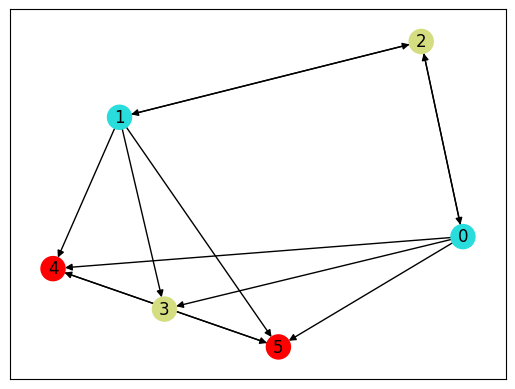

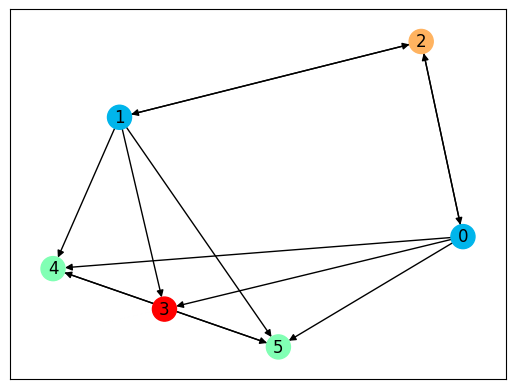

LEP 0: [0]
[0, 1]
  Divisor spectrum (eigenvalues): [0.]
  Divisor eigenvectors (columns):
[[1.]]
  Local spectrum (eigenvalues): [0. 0.]
  Local eigenvectors (columns):
[[1. 0.]
 [0. 1.]]
LEP 1: [1]
[2, 3]
  Divisor spectrum (eigenvalues): [0.]
  Divisor eigenvectors (columns):
[[1.]]
  Local spectrum (eigenvalues): [0. 0.]
  Local eigenvectors (columns):
[[1. 0.]
 [0. 1.]]
LEP 2: [2]
[4, 5]
  Divisor spectrum (eigenvalues): [1.]
  Divisor eigenvectors (columns):
[[1.]]
  Local spectrum (eigenvalues): [ 1. -1.]
  Local eigenvectors (columns):
[[ 0.7 -0.7]
 [ 0.7  0.7]]
OVERALL DIVISOR GRAPH
Eigenvalues: [ 1.   1.4 -1.4]
Transmitting Eigenvalues: [0. 1. 0. 0.]
Eigenvectors (columns):
[[ 0.   0.2  0.5]
 [ 0.   0.3 -0.7]
 [ 1.   0.9 -0.4]]
Transmitting Eigenvectors (columns):
[[ 0.   0.7 -0.7  0.7]
 [ 0.   0.   0.   0. ]
 [ 1.   0.7  0.   0. ]
 [ 0.   0.   0.7 -0.7]]
FULL GRAPH
Has eigenbasis? True
Spectrum (eigenvalues): [-1.4 -0.   1.4  1.  -1.   0. ]
Eigenvectors (columns):
[[ 0.5 -0.

In [82]:
# Run with a small example (n=8)
G, ep, leps = run_directed_lep_analysis(6, edge_prob=.25, vecs=True, round_val=1, plot=True, nt_perc = .6, directed=True)


In [ ]:
triforce = np.array([[0,0,0,0,1,0],
                     [0,0,0,1,0,1],
                     [0,0,0,0,0,1],
                     [1,1,0,0,1,0],
                     [0,0,1,1,0,1],
                     [0,0,0,1,1,0]])

rep,rlep = epu.getEquitablePartitions(triforce)
tep,tlep = epu.getEquitablePartitions(triforce.T)

array([0.57735027, 0.57735027, 0.57735027])

In [33]:
epu.ValidateMethod(G)

Counter({np.complex128(0j): 6})
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


np.True_

In [5]:
def show_ep_and_divisor_matrix(n, edge_prob=0.25, seed=None):
    """
    Create a random directed network of size n, find the equitable partition,
    plot the graph colored by equitable partition, and print the divisor matrix.
    Only runs on a graph whose equitable partition has at least 80% non-singleton cells; retries until found or 10s timeout.
    """
    from matplotlib import pyplot as plt
    
    start = time.perf_counter()
    timeout_sec = 10
    attempt = 0
    while True:
        if time.perf_counter() - start > timeout_sec:
            raise TimeoutError("Could not find a graph with ≥80% non-singleton partition elements within 10 seconds")
        seed_i = (seed + attempt) if seed is not None else None
        G = nx.gnp_random_graph(n, edge_prob, seed=seed_i, directed=True)
        G = nx.convert_node_labels_to_integers(G)
        # G = G.reverse()
        ep, _ = epu.getEquitablePartitions(G, progress_bars=False)
        n_el = len(ep)
        n_non_singleton = sum(1 for nodes in ep.values() if len(nodes) > 1)
        if n_non_singleton >= 0.8 * n_el:
            break
        attempt += 1
    
    div_mat = g.genDivGraph(G, ep, retMat=True)
    ep_ids = list(ep.keys())
    
    # Plot graph colored by equitable partition
    epu.plotEquitablePartition(G, ep)
    
    # Print divisor matrix with row/column labels = partition element id
    print("Equitable partition (element_id -> list of node ids):", ep)
    print("\nDivisor matrix (row i = partition element ep_ids[i], col j = partition element ep_ids[j]); entry = # edges from cell i to cell j:")
    print("Partition element ids (rows/cols):", ep_ids)
    print(div_mat)

In [6]:
from importlib import reload as r
r(g)

<module 'graphs' from '/Users/rental/Desktop/Work/Research/EquitablePartitions/src/graphs.py'>

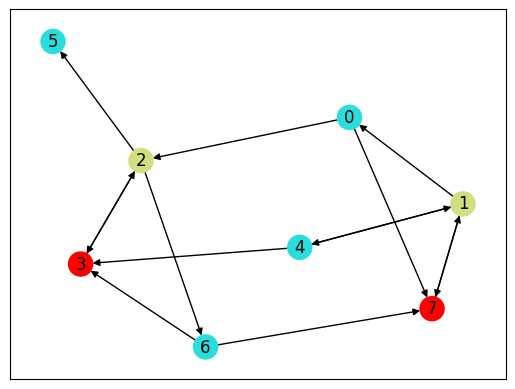

Equitable partition (element_id -> list of node ids): {0: [0, 4, 5, 6], 1: [1, 2], 2: [3, 7]}

Divisor matrix (row i = partition element ep_ids[i], col j = partition element ep_ids[j]); entry = # edges from cell i to cell j:
Partition element ids (rows/cols): [0, 1, 2]
[[0. 1. 0.]
 [1. 0. 1.]
 [2. 1. 0.]]


In [7]:
# Example: show colored graph and divisor matrix for a small directed network
show_ep_and_divisor_matrix(8, edge_prob=0.3)